# **Pymc Discounted Cash Flows (DCF) Modeling with PyMC**

## Discounted Cash Flows (DCF) Model for mv_pymc_dcf_pt materialized view

### Covers all pymc models from :
- `probabilistic_ml_model.pymc_models.DCF_PriceTargetModel.DCFPriceTarget` — Bayesian DCF intrinsic-value model with DB-aligned `pm.Data` containers (`price_target`, `dcf_features`, `<coord>_idx`).
- `pml.mv_pymc_dcf_pt` — main dataframe for model analysis.
- `pml.vw_pymc_feature_catalogue` (model_target = `dcf_pt`) — drives the `dcf_feature` coord labels.


In [1]:
%%sql
SELECT * FROM pml.mv_pymc_dcf_pt mpeb

,isin,ticker,region,country,trading_country,exchange,unit,style_class,size_class,sector,...,feat_capex_to_fcf,feat_cfo_ltm,feat_tr_cagr_3y,feat_tr_cagr_10y,feat_peg_ntm,feat_ev_sales_ltm,feat_ev_ebitda_ntm,feat_roa_ltm,feat_gpm_ltm,feat_beta_5y
0,US67066G1040,NVDA,United States and Canada,US,US,NasdaqGS,USD,Growth,Large Cap,Information Technology,...,-0.055192,125648.00,0.7603,0.6881,0.49,20.4,17.2,0.5273,0.7415,2.24
1,US31816X1063,FLY,United States and Canada,US,US,NasdaqGM,USD,Core,Small Cap,Industrials,...,0.180695,-210.93,NaN,NaN,NaN,31.8,NaN,-0.1682,0.2483,NaN
2,US5502411037,LUMN,United States and Canada,US,US,NYSE,USD,Value,Mid Cap,Communication Services,...,-10.109620,4966.00,0.7043,-0.0415,NaN,1.8,7.0,-0.0075,0.4731,1.66
3,US24823R1059,DNLI,United States and Canada,US,US,NasdaqGS,USD,Core,Small Cap,Health Care,...,0.016435,-412.34,-0.1453,NaN,NaN,NaN,NaN,-0.2695,NaN,1.00
4,US0378331005,AAPL,United States and Canada,US,US,NasdaqGS,USD,Core,Large Cap,Information Technology,...,-0.085528,140222.00,0.2021,0.3011,3.03,10.0,25.9,0.2623,0.4786,1.06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6275,BRVVEOACNOR0,VVEO3,Latin America and Caribbean,BR,BR,BOVESPA,BRL,Value,Small Cap,Health Care,...,-0.159111,64.69,-0.5672,NaN,NaN,0.3,5.0,0.0387,0.1491,NaN
6276,BRQUALACNOR6,QUAL3,Latin America and Caribbean,BR,BR,BOVESPA,BRL,Value,Small Cap,Health Care,...,-0.002385,46.24,-0.3099,-0.1759,0.05,0.9,2.3,0.0464,0.8747,NaN
6277,TRELKMH00013,LKMNH,Africa / Middle East,TR,TR,IBSE,TRY,Core,Small Cap,Health Care,...,NaN,NaN,0.7071,0.4920,NaN,1.4,4.8,0.0613,0.1888,NaN
6278,BRLJQQACNOR5,LJQQ3,Latin America and Caribbean,BR,BR,BOVESPA,BRL,Value,Small Cap,Consumer Discretionary,...,-0.055517,122.62,-0.3405,NaN,NaN,0.7,9.6,0.0000,0.3177,0.46


In [2]:
%%sql
SELECT * FROM pml.vw_pymc_feature_catalogue WHERE model_target = 'dcf_pt'

,model_target,pymc_role,column_name,category,feature_role,feature_alias,data_type,description
0,dcf_pt,mutable_predictor,ev_sales_ntm,valuation,predictor,ev_sales_ntm,double precision,Enterprise value to sales (period indicated by...
1,dcf_pt,mutable_predictor,ev_ebitda_ltm,valuation,predictor,ev_ebitda_ltm,double precision,Enterprise value to EBITDA (period indicated b...
2,dcf_pt,mutable_predictor,ev_ebitda_ntm,valuation,predictor,feat_ev_ebitda_ntm,double precision,Enterprise value to EBITDA (period indicated b...
3,dcf_pt,mutable_predictor,ev_ebitda_est_fy1,valuation,predictor,ev_ebitda_est_fy1,double precision,Enterprise value to EBITDA (period indicated b...
4,dcf_pt,mutable_predictor,enterprise_value,market_data,predictor,enterprise_value,double precision,Enterprise value
...,...,...,...,...,...,...,...,...
117,dcf_pt,coord,unit,classification,categorical,unit,text,Reporting currency unit
118,dcf_pt,coord,style_class,classification,categorical,style_class,text,Investment style classification (growth/value/...
119,dcf_pt,coord,size_class,classification,categorical,size_class,text,Market cap size classification (large/mid/small)
120,dcf_pt,coord,sector,classification,categorical,sector,text,GICS business sector


## 1. Notebook Setup & Imports

Shared imports for EDA, schema-aligned summary statistics, PyMC modelling, and prior/posterior predictive diagnostics. The `dcf_df` and `feature_catalogue` DataFrames produced by the two `%%sql` cells above are reused throughout.


In [3]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# --- ArviZ 1.0 backend resolution -------------------------------------------
# ArviZ 1.x ships as three packages: `arviz-base` (data containers),
# `arviz-stats` (diagnostics, e.g. `az.summary`) and `arviz-plots`
# (visualization, e.g. `plot_ppc_dist`). The legacy top-level `arviz.plot_ppc`
# no longer exists. Bind the *stats/base* namespace as `az` and the *plotting*
# namespace as `azp` once here so every downstream cell stays in sync.
try:
    import arviz as az
except ImportError:  # ArviZ 1.0 split packages
    import arviz_base as az  # type: ignore

try:
    import arviz_plots as azp  # ArviZ 1.0 plotting package
    _HAS_AZP = True
except ImportError:  # legacy ArviZ (<1.0) - plotting lives on `az`
    azp = az  # type: ignore[assignment]
    _HAS_AZP = False

import pymc as pm

warnings.filterwarnings('ignore', category=FutureWarning)
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)


# --- Reusable ArviZ-1.0-aware predictive-check helpers ----------------------
def _resolve_pred_group(idata, group: str) -> str:
    """Resolve the predictive group name actually present on `idata`.

    PyMC's `sample_prior_predictive` / `sample_posterior_predictive` may store
    observed-variable draws either under '<group>_predictive' (canonical) or,
    in some builds, alongside the parameter draws under '<group>'. This helper
    inspects the available groups on the DataTree / InferenceData and returns
    the predictive group when present, otherwise the base group.
    """
    short = group[: -len('_predictive')] if group.endswith('_predictive') else group
    predictive = f'{short}_predictive'
    available = set(getattr(idata, 'groups', lambda: [])()) if callable(
        getattr(idata, 'groups', None)
    ) else set(getattr(idata, 'groups', []) or [])
    # DataTree exposes child group names as keys; fall back to attribute probe.
    if not available:
        available = {name for name in (short, predictive)
                     if getattr(idata, name, None) is not None}
    if predictive in available:
        return predictive
    if short in available:
        return short
    return predictive  # let ArviZ raise an informative error if neither exists


def figure_from_ppc(pc) -> plt.Figure:
    """Return the matplotlib Figure backing an ArviZ predictive-check plot.

    Handles both the ArviZ 1.0 `PlotCollection` return type (which exposes a
    `.viz['figure']` xarray container) and the legacy `Axes` / array-of-`Axes`
    return type, falling back to the current pyplot figure.
    """
    viz = getattr(pc, 'viz', None)
    if viz is not None and 'figure' in viz:
        fig = viz['figure'].item()
        if fig is not None:
            return fig
    if hasattr(pc, 'figure'):  # bare Axes
        return pc.figure
    flat = np.ravel(pc)  # array of Axes
    if flat.size and hasattr(flat[0], 'figure'):
        return flat[0].figure
    return plt.gcf()


def plot_ppc(idata, *, group: str = 'posterior', var_names=None,
             title: str | None = None, num_pp_samples: int = 100,
             **kwargs) -> plt.Figure:
    """ArviZ-1.0-aware (prior|posterior) predictive density check.

    Uses `arviz_plots.plot_ppc_dist` (continuous PPC density overlay) when the
    1.0 plotting package is available, otherwise falls back to the legacy
    `arviz.plot_ppc`. The predictive group is resolved against the groups that
    actually exist on `idata` (see `_resolve_pred_group`), so it works whether
    PyMC stored the observed-variable draws under '<group>' or
    '<group>_predictive'.
    """
    pred_group = _resolve_pred_group(idata, group)
    if _HAS_AZP:
        # ArviZ 1.0 renamed `num_pp_samples` -> `num_samples` in plot_ppc_dist.
        pc = azp.plot_ppc_dist(idata, group=pred_group, var_names=var_names,
                               num_samples=num_pp_samples, **kwargs)
    else:  # legacy ArviZ (<1.0)
        pc = azp.plot_ppc(idata, group=group, var_names=var_names,
                          num_pp_samples=num_pp_samples, **kwargs)
    fig = figure_from_ppc(pc)
    if title:
        fig.suptitle(title)
        fig.tight_layout()
    return fig


# --- Dark theme for all plots ------------------------------------------------
# Matplotlib dark background + seaborn dark grid keep ArviZ / pandas / seaborn
# figures visually consistent. Try ArviZ's bundled dark stylesheet first; if
# unavailable, fall back to matplotlib's built-in 'dark_background'.
plt.style.use('dark_background')
try:
    azp.style.use('arviz-darkgrid')
except (OSError, ValueError, AttributeError):
    pass
sns.set_theme(style='darkgrid', context='notebook',
              rc={
                  'figure.facecolor': '#1e1e1e',
                  'axes.facecolor': '#2a2a2a',
                  'savefig.facecolor': '#1e1e1e',
                  'axes.edgecolor': '#cccccc',
                  'axes.labelcolor': '#e6e6e6',
                  'xtick.color': '#e6e6e6',
                  'ytick.color': '#e6e6e6',
                  'text.color': '#e6e6e6',
                  'grid.color': '#555555',
              })
plt.rcParams['figure.dpi'] = 110

print(f'dcf_df: {dcf_df.shape}')
print(f'feature_catalogue: {feature_catalogue.shape}')


dcf_df: (6280, 36)
feature_catalogue: (122, 8)


C:\Users\markm\PML_Finance_Project\.venv\Lib\site-packages\pytensor\configparser.py:309: UserWarning: PyTensor does not recognise this flag: device
  warnings.warn(f"PyTensor does not recognise this flag: {key}")


## 2. Exploratory Data Analysis (EDA) — `dcf_df`

Schema-aligned EDA driven by `feature_catalogue` (the `vw_pymc_feature_catalogue` view for `model_target = 'dcf_pt'`). We split columns by `pymc_role` (`response`, `mutable_predictor`, `coord`) and `feature_role` to drive shape, missingness, and distribution checks.


In [4]:
# Map feature_catalogue -> columns actually present in dcf_df
catalogue = feature_catalogue.copy()
catalogue['present'] = catalogue['feature_alias'].isin(dcf_df.columns)

role_summary = (
    catalogue.groupby(['pymc_role', 'feature_role'])['present']
    .agg(n_columns='size', n_present='sum')
    .reset_index()
)
role_summary


,pymc_role,feature_role,n_columns,n_present
0,coord,categorical,9,9
1,derived_input,historical,70,0
2,mutable_predictor,predictor,40,17
3,observed,target,3,3


In [5]:
# Resolve column groups by pymc_role
present = catalogue.loc[catalogue['present']]
PREDICTOR_COLS = present.loc[present['pymc_role'] == 'mutable_predictor', 'feature_alias'].tolist()
COORD_COLS = present.loc[present['pymc_role'] == 'coord', 'feature_alias'].tolist()
RESPONSE_COLS = present.loc[present['pymc_role'].isin(['response', 'observed']), 'feature_alias'].tolist()

# Fall back to the canonical DCF response column if not tagged in catalogue
for col in ('observed_pt',):
    if col in dcf_df.columns and col not in RESPONSE_COLS:
        RESPONSE_COLS.append(col)

# Build source-column -> MV alias mapping from the catalogue. The catalogue
# view now exposes the per-model `feature_alias` populated by
# pml.pml_df_feature_alias, so downstream code can address columns by their
# materialized-view alias (e.g. feat_eps_fy1e, observed_target_pct, n_beats,
# region/country/sector classification coords).
if 'feature_alias' in catalogue.columns:
    ALIAS_MAP = (
        present.dropna(subset=['feature_alias'])
        .set_index('column_name')['feature_alias']
        .to_dict()
    )
else:
    ALIAS_MAP = {c: c for c in present['column_name']}

print(f'#predictors : {len(PREDICTOR_COLS)}')
print(f'#coords     : {len(COORD_COLS)}  -> {COORD_COLS}')
print(f'#response   : {len(RESPONSE_COLS)} -> {RESPONSE_COLS}')
print(f'#aliases    : {len(ALIAS_MAP)} (source_column -> mv_alias)')


#predictors : 17
#coords     : 9  -> ['region', 'country', 'trading_country', 'exchange', 'unit', 'style_class', 'size_class', 'sector', 'industry']
#response   : 3 -> ['observed_pt', 'feat_tr_cagr_3y', 'feat_tr_cagr_10y']
#aliases    : 29 (source_column -> mv_alias)


In [6]:
# 2.1 Shape, dtypes, missingness overview
missing = dcf_df.isna().mean().sort_values(ascending=False)
eda_overview = pd.DataFrame({
    'dtype': dcf_df.dtypes.astype(str),
    'missing_pct': missing.round(4),
    'n_unique': dcf_df.nunique(dropna=True),
})
eda_overview.head(20)


,dtype,missing_pct,n_unique
country,str,0.0000,83
enterprise_value,float64,0.0011,6258
exchange,str,0.0000,82
feat_beta_5y,float64,0.0994,367
feat_capex_to_fcf,float64,0.0398,6021
feat_cfo_ltm,float64,0.0288,5917
feat_ev_ebitda_ntm,float64,0.0769,577
feat_ev_sales_ltm,float64,0.0283,395
feat_fcf_fy1e,float64,0.0979,5419
feat_fcf_fy2e,float64,0.0992,5440


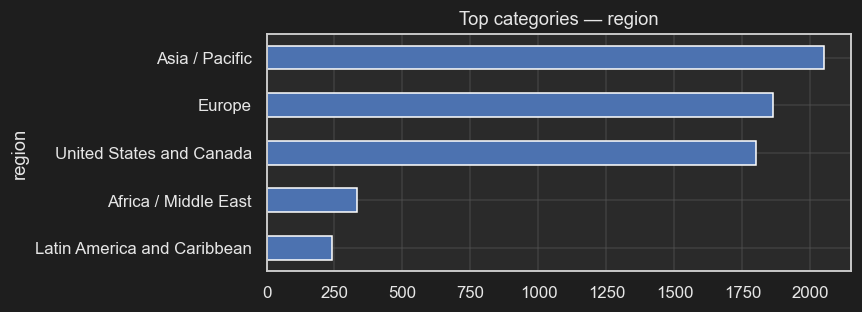

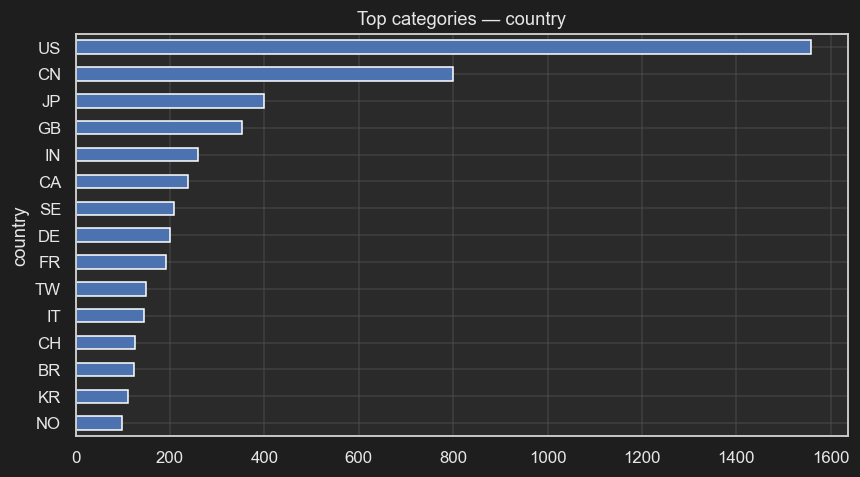

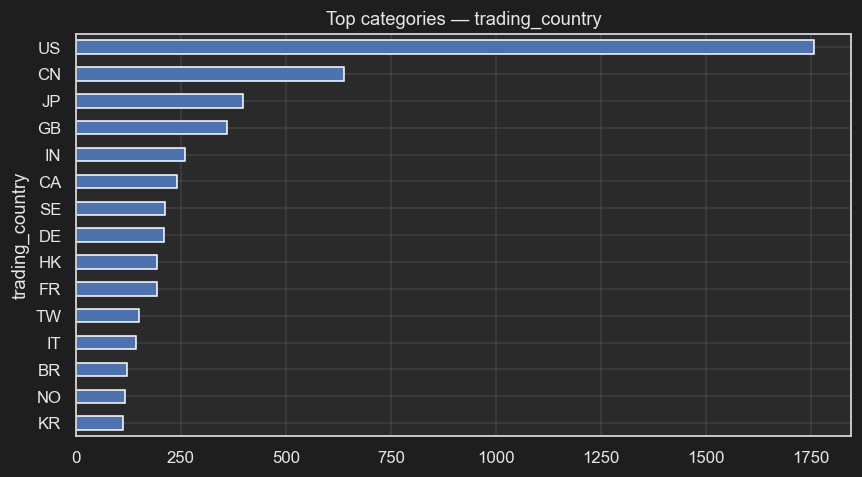

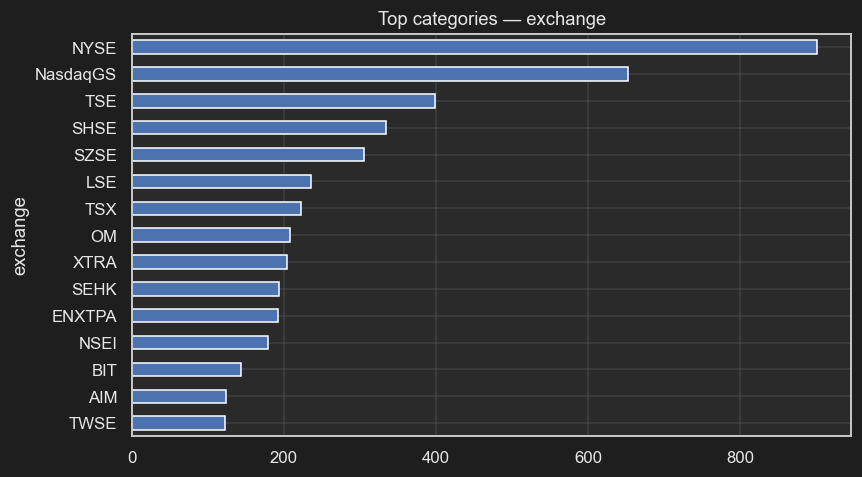

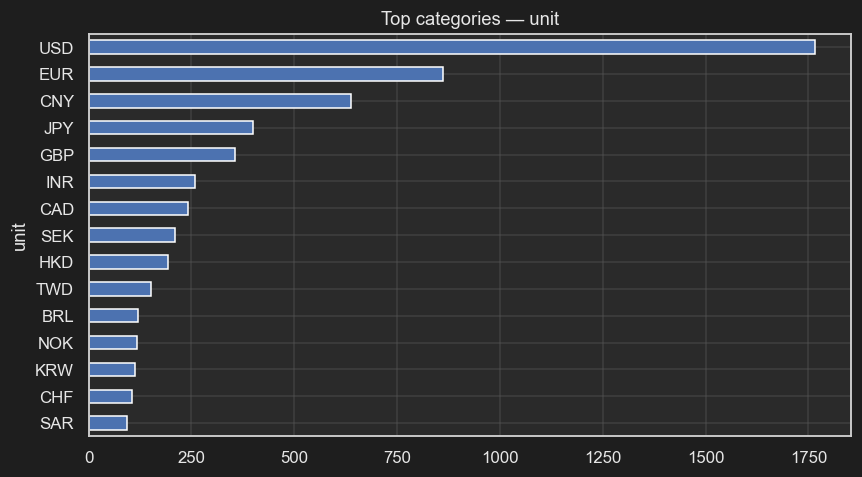

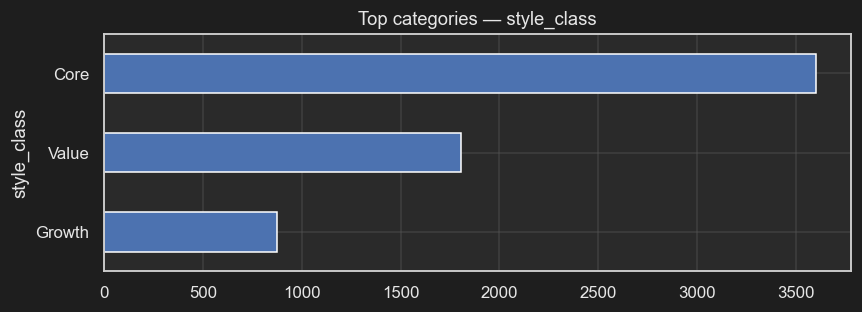

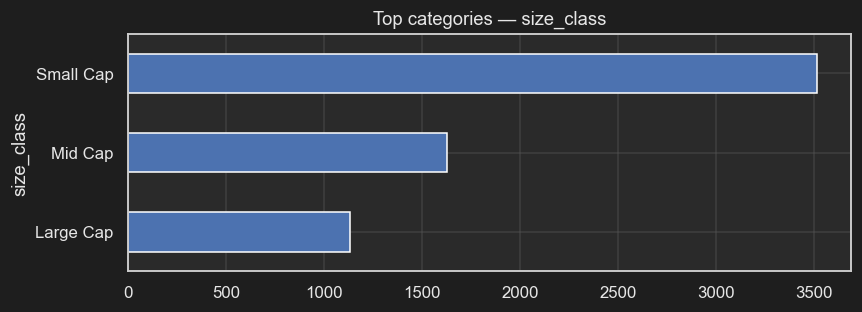

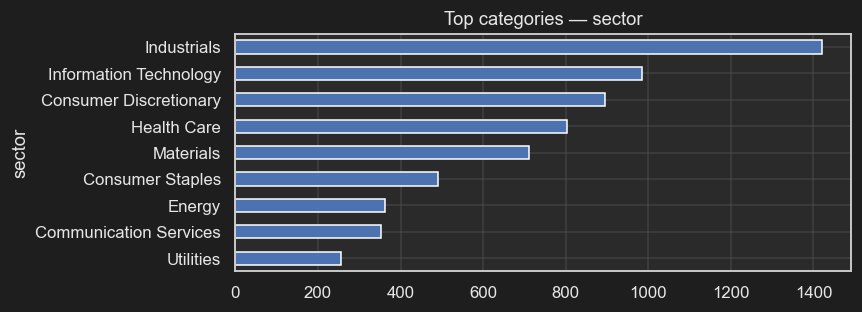

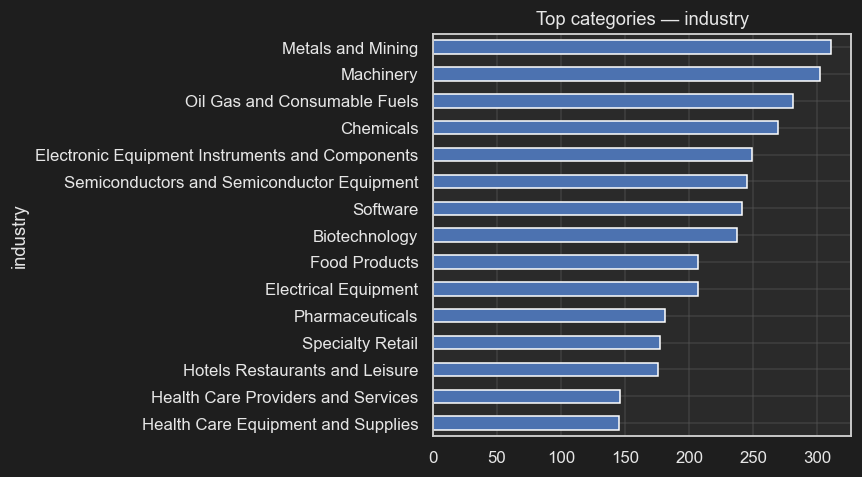

In [7]:
# 2.3 Coord-level counts (sector / industry / next_earnings_status)
for col in COORD_COLS:
    counts = dcf_df[col].value_counts(dropna=False).head(15)
    fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * len(counts))))
    counts.sort_values().plot.barh(ax=ax)
    ax.set_title(f'Top categories — {col}')
    plt.tight_layout()
    plt.show()


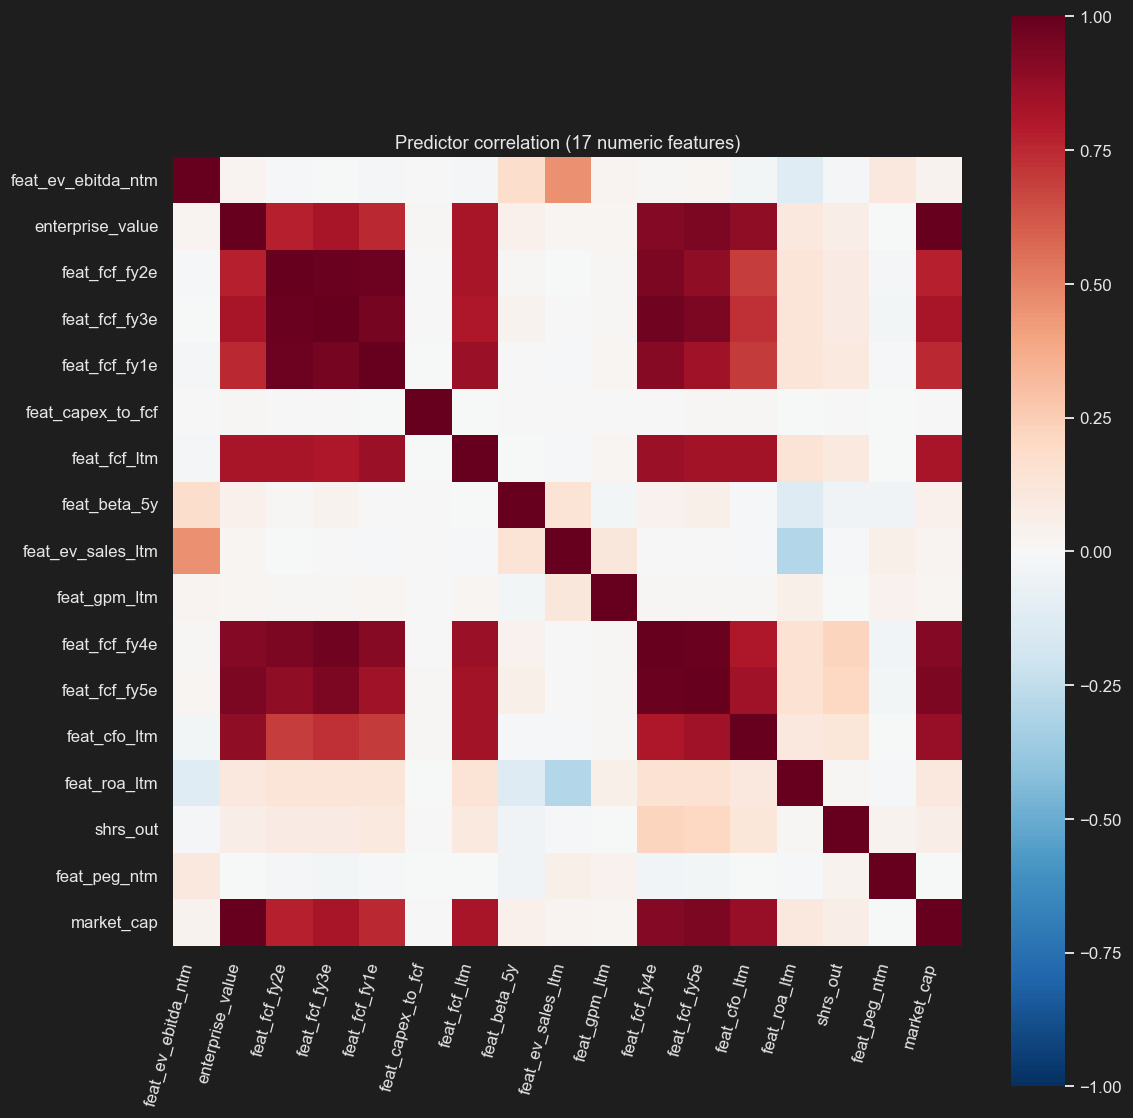

In [8]:
# 2.4 Predictor correlation heatmap (numeric predictors only)
num_predictors = [c for c in PREDICTOR_COLS
                  if pd.api.types.is_numeric_dtype(dcf_df[c])]

if len(num_predictors) < 2:
    print(f'⚠️ Predictor correlation heatmap skipped — '
          f'only {len(num_predictors)} numeric predictor(s) available '
          f'(need ≥ 2). Check that `feature_catalogue` tags '
          f'`mutable_predictor` columns that actually exist in `dcf_df`.')
else:
    corr = dcf_df[num_predictors].corr(numeric_only=True)
    side = min(14, 0.4 * len(num_predictors) + 4)
    fig, ax = plt.subplots(figsize=(side, side))
    # Only render tick labels when the matrix is small enough to read them.
    show_labels = len(num_predictors) <= 30
    sns.heatmap(
        corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        xticklabels=show_labels, yticklabels=show_labels,
        square=True, ax=ax,
    )
    if show_labels:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=75, ha='right')
    ax.set_title(f'Predictor correlation ({len(num_predictors)} numeric features)')
    plt.tight_layout()
    plt.show()


## 3. Summary Statistics by Feature Role

Statistics are grouped using `feature_catalogue.feature_role` (e.g. `predictor`, `cash_flow`, `categorical`) and `category` (e.g. `eps_cash_flows`, `fiscal_calendar`, `classification`). This mirrors the catalogue-driven approach used in `pymc_expected_returns_model.ipynb` §13 (catalogue-driven coverage check).


In [9]:
def summarize_by_role(df: pd.DataFrame, cat: pd.DataFrame) -> pd.DataFrame:
    """Aggregate per-column statistics, joined with feature_catalogue metadata.

    The catalogue uses two identifiers:
      - ``column_name``   — source column in ``pml.pml_df``
      - ``feature_alias`` — MV/view alias actually exposed in ``dcf_df``
        (populated from ``pml.pml_df_feature_alias`` per ``model_target``).

    Rows in ``dcf_df`` are addressable by alias, so we resolve presence by
    alias first and fall back to ``column_name`` for catalogue rows that pass
    the source column through unchanged (most ``coord`` entries).
    """
    numeric_fields = ['mean', 'std', 'p05', 'median', 'p95', 'skew', 'kurt']

    # 1. Resolve, for each catalogue row, which df column (if any) backs it.
    has_alias = 'feature_alias' in cat.columns
    cat = cat.copy()
    cat['resolved_column'] = (
        cat['feature_alias'].where(has_alias and cat['feature_alias'].notna(),
                                   cat['column_name'])
        if has_alias else cat['column_name']
    )
    # Keep only rows whose resolved name exists in the dataframe, de-duplicated
    # (a single MV alias can be referenced by multiple source columns).
    resolved = (
        cat.loc[cat['resolved_column'].isin(df.columns)]
        .drop_duplicates(subset=['resolved_column'])
    )

    # 2. Per-column statistics keyed by the resolved (df-side) column name.
    rows = []
    for col in resolved['resolved_column']:
        s = df[col]
        rec = {
            'resolved_column': col,
            'dtype': str(s.dtype),
            'n': int(s.notna().sum()),
            'missing_pct': float(s.isna().mean()),
            'n_unique': int(s.nunique(dropna=True)),
        }
        # Ensure numeric stat columns always exist (NaN for non-numeric dtypes)
        for f in numeric_fields:
            rec[f] = np.nan
        if pd.api.types.is_numeric_dtype(s):
            desc = s.describe(percentiles=[0.05, 0.5, 0.95])
            rec.update({
                'mean': float(desc['mean']),
                'std': float(desc['std']),
                'p05': float(desc['5%']),
                'median': float(desc['50%']),
                'p95': float(desc['95%']),
                'skew': float(s.skew(skipna=True)),
                'kurt': float(s.kurt(skipna=True)),
            })
        rows.append(rec)

    stats = pd.DataFrame(rows)

    # 3. Merge metadata back. Use ``resolved_column`` as the join key so every
    #    feature category (coord, mutable_predictor, constant_data, observed)
    #    keeps its catalogue annotations. Rename the catalogue's source
    #    ``column_name`` to ``source_column_name`` BEFORE the merge so it does
    #    not collide with the alias-based ``column_name`` we surface below.
    meta_cols = [c for c in
                 ['column_name', 'pymc_role', 'feature_role',
                  'feature_alias', 'category', 'data_type']
                 if c in cat.columns]
    meta_df = resolved[['resolved_column', *meta_cols]].rename(
        columns={'column_name': 'source_column_name'}
    )
    out = stats.merge(meta_df, on='resolved_column', how='left')

    # 4. Surface a stable ``column_name`` (= MV/df-side alias) for downstream
    #    code that filters dcf_df by alias (e.g. the cash_flow box plot).
    out = out.rename(columns={'resolved_column': 'column_name'})

    # Reorder for readability
    leading = ['column_name', 'feature_alias', 'source_column_name',
               'pymc_role', 'feature_role',
               'category', 'data_type', 'dtype', 'n', 'missing_pct', 'n_unique']
    leading = [c for c in leading if c in out.columns]
    return out[leading + [c for c in out.columns if c not in leading]]


summary_stats = summarize_by_role(dcf_df, catalogue)
summary_stats.head(50)


,column_name,feature_alias,source_column_name,pymc_role,feature_role,category,data_type,dtype,n,missing_pct,n_unique,mean,std,p05,median,p95,skew,kurt
0,feat_ev_ebitda_ntm,feat_ev_ebitda_ntm,ev_ebitda_ntm,mutable_predictor,predictor,valuation,double precision,float64,5797,0.076911,577,14.284716,21.673755,3.700000,9.400000,37.520000,10.251152,154.913747
1,enterprise_value,enterprise_value,enterprise_value,mutable_predictor,predictor,market_data,double precision,float64,6273,0.001115,6258,22026.180156,137794.295261,186.036000,4127.790000,72762.680000,24.485093,736.537078
2,feat_fcf_fy2e,feat_fcf_fy2e,fcf_est_avg_fy2e,mutable_predictor,predictor,cash_flow,double precision,float64,5657,0.099204,5440,955.381206,6189.878328,-163.628000,192.160000,3444.006000,26.686241,934.466611
3,feat_fcf_fy3e,feat_fcf_fy3e,fcf_est_avg_fy3e,mutable_predictor,predictor,cash_flow,double precision,float64,4979,0.207166,4812,1224.350402,7762.030026,-102.634000,245.590000,4204.187000,26.554478,940.079065
4,feat_fcf_fy1e,feat_fcf_fy1e,fcf_est_avg_fy1e,mutable_predictor,predictor,cash_flow,double precision,float64,5665,0.097930,5419,760.746138,5005.825711,-289.932000,139.290000,2982.158000,24.901761,837.706952
5,feat_capex_to_fcf,feat_capex_to_fcf,capital_expenditure_ltm,mutable_predictor,predictor,cash_flow,double precision,float64,6030,0.039809,6021,-1.008183,31.235333,-4.217310,-0.245563,3.435995,-45.815165,2864.405025
6,feat_fcf_ltm,feat_fcf_ltm,fcf_ltm,mutable_predictor,predictor,cash_flow,double precision,float64,6099,0.028822,5897,584.721072,3504.987492,-359.140000,104.950000,2589.932000,20.788353,627.373704
7,observed_pt,observed_pt,price_target,observed,target,analyst_targets,double precision,float64,6279,0.000159,5563,6739.407139,72342.350436,2.632130,50.350000,5373.428600,20.452125,503.125680
8,feat_beta_5y,feat_beta_5y,beta_5y,mutable_predictor,predictor,volatility,double precision,float64,5656,0.099363,367,0.785575,0.634909,0.010000,0.710000,1.820000,1.217966,24.889757
9,feat_tr_cagr_3y,feat_tr_cagr_3y,tot_return_pct_cagr_3y,observed,target,total_return,double precision,float64,5869,0.065446,4415,0.165914,0.344114,-0.245160,0.107200,0.791040,1.849393,6.829152


In [10]:
# 3.1 Roll-up by (pymc_role, feature_role, feature_alias, category)
rollup = (
    summary_stats
    .groupby(['pymc_role', 'feature_role', 'feature_alias', 'category'], dropna=False)
    .agg(
        n_columns=('feature_alias', 'size'),
        avg_missing_pct=('missing_pct', 'mean'),
        mean_of_means=('mean', 'mean'),
        mean_of_stds=('std', 'mean'),
    )
    .round(4)
    .reset_index()
    .sort_values(['pymc_role', 'feature_role', 'feature_alias', 'category'])
)
rollup


,pymc_role,feature_role,feature_alias,category,n_columns,avg_missing_pct,mean_of_means,mean_of_stds
0,coord,categorical,country,classification,1,0.0000,NaN,NaN
1,coord,categorical,exchange,classification,1,0.0000,NaN,NaN
2,coord,categorical,industry,classification,1,0.0000,NaN,NaN
3,coord,categorical,region,classification,1,0.0000,NaN,NaN
4,coord,categorical,sector,classification,1,0.0000,NaN,NaN
5,coord,categorical,size_class,classification,1,0.0000,NaN,NaN
6,coord,categorical,style_class,classification,1,0.0000,NaN,NaN
7,coord,categorical,trading_country,classification,1,0.0000,NaN,NaN
8,coord,categorical,unit,classification,1,0.0000,NaN,NaN
9,mutable_predictor,predictor,enterprise_value,market_data,1,0.0011,22026.1802,137794.2953


C:\Users\markm\AppData\Local\Temp\ipykernel_12788\4154807416.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=75, ha='right')


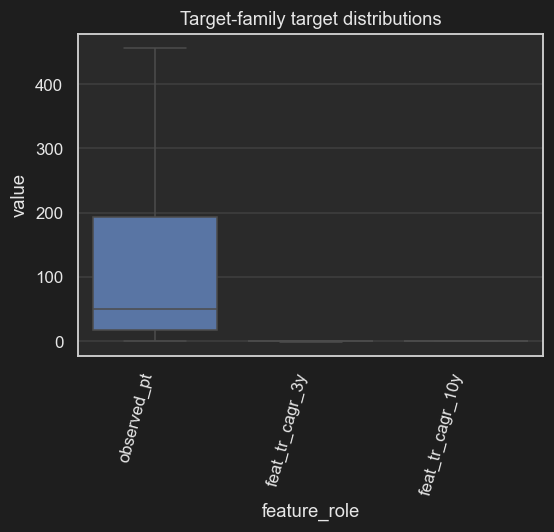

In [11]:
# 3.2 Visualise distribution of target-family targets per category
#     Iterate feature_aliases for the 'target' feature_role and map them
#     onto dcf_df columns (the MV exposes columns by feature_alias).
rev_aliases = (
    summary_stats.loc[summary_stats['feature_role'] == 'target',
    'feature_alias']
    .dropna()
    .unique()
    .tolist()
)
rev_cols = [a for a in rev_aliases if a in dcf_df.columns
            and pd.api.types.is_numeric_dtype(dcf_df[a])]
if rev_cols:
    melted = dcf_df[rev_cols].melt(var_name='feature_role', value_name='value').dropna()
    fig, ax = plt.subplots(figsize=(min(14, 0.4 * len(rev_cols) + 4), 5))
    sns.boxplot(data=melted, x='feature_role', y='value', ax=ax, showfliers=False)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=75, ha='right')
    ax.set_title('Target-family target distributions')
    plt.tight_layout()
    plt.show()
else:
    print('No target-role targets present in dcf_df.')


## 4. Build PyMC-Aligned Data Containers

We follow the `DCF_PriceTargetModel.py` schema (see `probabilistic_ml_model/pymc_models/DCF_PriceTargetModel`): Places priors on FCF growth rate and WACC, computes projected FCFs and
terminal value as PyMC Deterministics, and fits against observed analyst price targets. This section prepares the inputs but uses a self-contained PyMC model so the notebook can run without re-fitting the full production pipeline.

**Schema alignment with `pml.mv_pymc_dcf_pt`.** The model coords include every categorical column emitted by the materialized view (DDL columns `region`, `country`, `trading_country`, `exchange`, `unit`, `style_class`, `size_class`, `sector`, `industry`). Each coord is registered as a `pm.Model` dimension and as a `pm.Data('<coord>_idx', …, dims='isin')` integer-index container, so posterior predictive checks can be conditioned on any of them via `pm.set_data`. Hierarchical partial-pooling effects are attached to `sector`, `size_class`, and `style_class` (the highest-signal, lowest-cardinality coords); the remaining coords are available for downstream slicing without inflating the parameter count.


In [12]:
# 4.0  Select rows with a usable response and an FCF anchor
SCALE_COLS = ['market_cap', 'enterprise_value', 'shrs_out']
FCF_LADDER = ['feat_fcf_ltm', 'feat_fcf_fy1e', 'feat_fcf_fy2e',
              'feat_fcf_fy3e', 'feat_fcf_fy4e', 'feat_fcf_fy5e']

model_df = dcf_df.loc[
    dcf_df['observed_pt'].notna()
    & dcf_df['feat_fcf_ltm'].notna()
].copy().reset_index(drop=True)
print(f'Modelling rows (observed_pt & feat_fcf_ltm present): {len(model_df)}')

isin_labels = model_df['isin'].astype(str).values


Modelling rows (observed_pt & feat_fcf_ltm present): 6098


In [13]:
# 4.0b  Categorical coords: every `coord` column present in pml.mv_pymc_dcf_pt.
# `feat_next_earnings_status` is NOT in the DCF MV, so it is excluded.
DCF_COORD_COLS = ['region', 'country', 'trading_country', 'exchange', 'unit',
                  'style_class', 'size_class', 'sector', 'industry']
CATEGORICAL_COORDS = [c for c in DCF_COORD_COLS if c in model_df.columns]
print(f'Categorical coords ({len(CATEGORICAL_COORDS)}): {CATEGORICAL_COORDS}')

coord_uniques, coord_idx = {}, {}
for col in CATEGORICAL_COORDS:
    labels = model_df[col].fillna('Unknown').astype(str).values
    uniques, idx = np.unique(labels, return_inverse=True)
    coord_uniques[col] = uniques
    coord_idx[col] = idx.astype('int64')

# Hierarchical partial-pooling effects on the lowest-cardinality coords.
GROUP_EFFECTS = [c for c in ('sector', 'size_class', 'style_class')
                 if c in CATEGORICAL_COORDS]
print(f'Group-effect coords: {GROUP_EFFECTS}')


Categorical coords (9): ['region', 'country', 'trading_country', 'exchange', 'unit', 'style_class', 'size_class', 'sector', 'industry']
Group-effect coords: ['sector', 'size_class', 'style_class']


In [14]:
# 4.1  Build the FCF projection ladder and a per-isin historical growth anchor.
# We use the analyst FCF estimates directly when present (feat_fcf_fy1e..fy5e);
# otherwise we fall back to last_fcf * (1+g)^t using feat_fcf_growth_1y.
N_PROJ = 5
last_fcf = model_df['feat_fcf_ltm'].astype(float).to_numpy()

fcf_est = model_df[['feat_fcf_fy1e', 'feat_fcf_fy2e', 'feat_fcf_fy3e',
                    'feat_fcf_fy4e', 'feat_fcf_fy5e']].astype(float).to_numpy()

# Per-isin historical growth: prefer the precomputed 1y FCF growth ratio.
hist_growth = (
    model_df.get('feat_fcf_growth_1y', pd.Series(0.0, index=model_df.index))
    .astype(float).fillna(0.0).clip(-0.5, 1.0).to_numpy()
)
# Terminal growth proxy (bounded below WACC support).
term_growth = (
    model_df.get('feat_fcf_terminal_growth', pd.Series(0.02, index=model_df.index))
    .astype(float).fillna(0.02).clip(-0.02, 0.04).to_numpy()
)

# Fill any missing FCF estimates from the geometric projection.
t = np.arange(1, N_PROJ + 1, dtype='float64')
proj_fallback = last_fcf[:, None] * (1.0 + hist_growth[:, None]) ** t[None, :]
fcf_proj_obs = np.where(np.isnan(fcf_est), proj_fallback, fcf_est)

observed_pt = model_df['observed_pt'].astype(float).to_numpy()
shrs_out = model_df['shrs_out'].astype(float).clip(lower=1.0).to_numpy()
print(f'FCF projection matrix: {fcf_proj_obs.shape} (N_isin, {N_PROJ})')


FCF projection matrix: (6098, 5) (N_isin, 5)


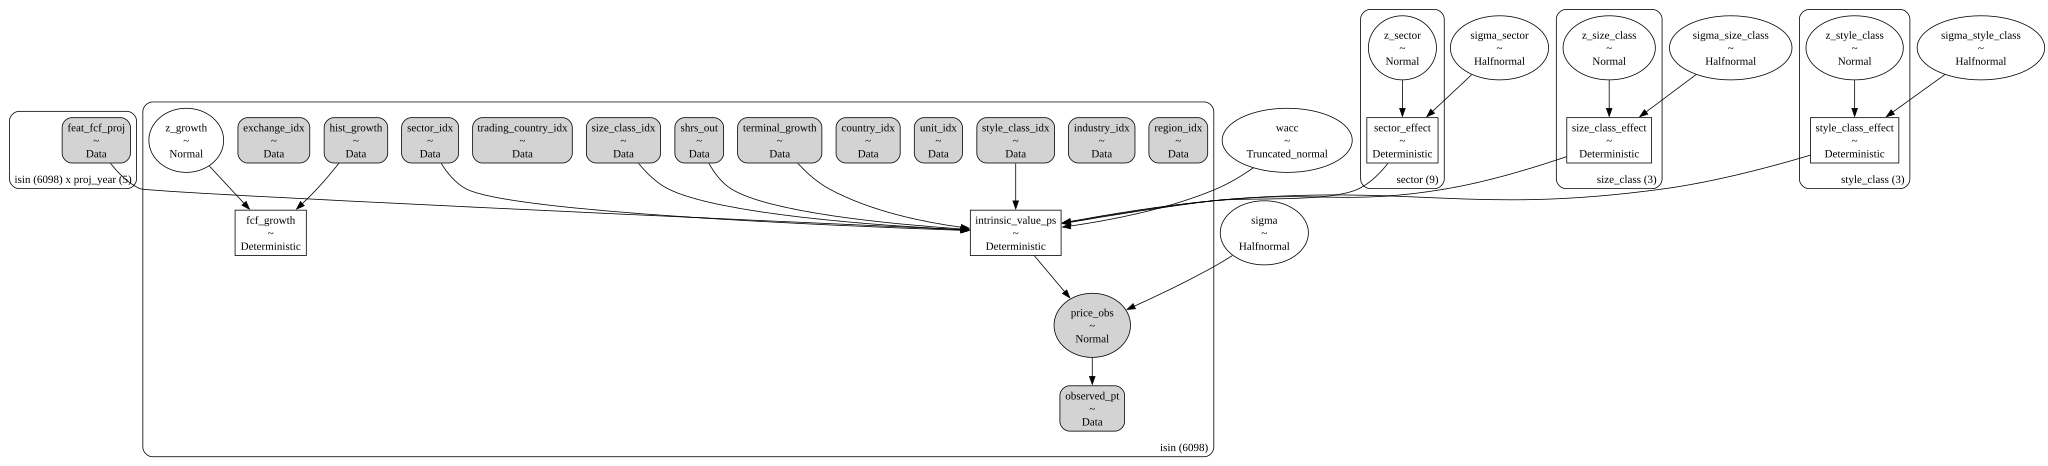

In [15]:
# 4.2  PyMC DCF model — Bayesian intrinsic value with hierarchical coord effects.
TERMINAL_GROWTH = 0.02

coords = {'isin': isin_labels, 'proj_year': np.arange(1, N_PROJ + 1)}
for _c in CATEGORICAL_COORDS:
    coords[_c] = coord_uniques[_c]

with pm.Model(coords=coords) as dcf_model:
    # ---- pm.Data containers (names mirror MV aliases / coords) ----
    fcf_data = pm.Data('feat_fcf_proj', fcf_proj_obs, dims=('isin', 'proj_year'))
    pt_obs = pm.Data('observed_pt', observed_pt, dims='isin')
    shrs_data = pm.Data('shrs_out', shrs_out, dims='isin')
    hg_data = pm.Data('hist_growth', hist_growth, dims='isin')
    tg_data = pm.Data('terminal_growth', term_growth, dims='isin')

    # One pm.Data per coord-indexed group → conditionable via pm.set_data.
    idx_data = {
        col: pm.Data(f'{col}_idx', coord_idx[col], dims='isin')
        for col in CATEGORICAL_COORDS
    }

    # ---- Priors on FCF growth and WACC (per the DCFPriceTarget schema) ----
    # Non-centred per-isin growth around the historical anchor.
    z_growth = pm.Normal('z_growth', 0.0, 1.0, dims='isin')
    fcf_growth = pm.Deterministic('fcf_growth', hg_data + 0.05 * z_growth, dims='isin')

    # WACC truncated strictly above terminal growth → finite Gordon terminal value.
    wacc = pm.TruncatedNormal('wacc', mu=0.10, sigma=0.02,
                              lower=TERMINAL_GROWTH + 0.005, upper=0.30)

    # ---- Projected PV of FCFs + terminal value (PyMC Deterministics) ----
    disc = (1.0 + wacc) ** coords['proj_year'].astype('float64')[None, :]
    pv_fcfs = pm.math.sum(fcf_data / disc, axis=1)              # dims: isin

    fcf_terminal = fcf_data[:, -1] * (1.0 + tg_data)
    terminal_value = fcf_terminal / (wacc - tg_data)
    terminal_pv = terminal_value / (1.0 + wacc) ** N_PROJ

    enterprise_iv = pv_fcfs + terminal_pv                      # firm-level IV

    # ---- Hierarchical partial-pooling adjustment (log-scale, →1.0) ----
    log_adj = 0.0
    for col in GROUP_EFFECTS:
        sigma_g = pm.HalfNormal(f'sigma_{col}', sigma=0.25)
        z_g = pm.Normal(f'z_{col}', 0.0, 1.0, dims=col)
        eff = pm.Deterministic(f'{col}_effect', sigma_g * z_g, dims=col)
        log_adj = log_adj + eff[idx_data[col]]

    # Per-share intrinsic value, comparable to the observed price target.
    intrinsic_ps = pm.Deterministic(
        'intrinsic_value_ps',
        (enterprise_iv * pm.math.exp(log_adj)) / shrs_data,
        dims='isin',
    )

    # ---- Likelihood: observed analyst price target ~ intrinsic value ----
    sigma = pm.HalfNormal('sigma', sigma=float(np.nanstd(observed_pt) or 1.0))
    pm.Normal('price_obs', mu=intrinsic_ps, sigma=sigma,
              observed=pt_obs, dims='isin')

pm.model_to_graphviz(dcf_model)


## 5. Prior Predictive Checks

Sample from the prior to verify that the FCF-growth / WACC priors and the hierarchical coord adjustments imply a plausible distribution of per-share intrinsic values relative to the observed analyst price targets (`observed_pt`).


C:\Users\markm\PML_Finance_Project\.venv\Lib\site-packages\pytensor\link\numba\dispatch\basic.py:214: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [price_obs, sigma, sigma_sector, sigma_size_class, sigma_style_class, wacc, z_growth, z_sector, z_size_class, z_style_class]


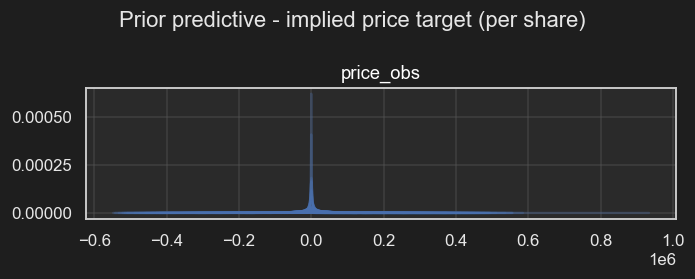

In [16]:
# 5.1  Prior predictive check
with dcf_model:
    prior_pc = pm.sample_prior_predictive(draws=500, random_seed=RANDOM_SEED)

fig = plot_ppc(prior_pc, group='prior', var_names=['price_obs'],
               num_pp_samples=100,
               title='Prior predictive - implied price target (per share)')
plt.show()


## 6. Fit & Posterior Predictive

Fit the DCF model with NUTS and draw from the posterior predictive to compare the modelled per-share intrinsic value against the observed analyst price targets.


In [17]:
# 6.1  Fit
with dcf_model:
    idata = pm.sample(draws=1000, tune=1000, chains=4, cores=1,
                      target_accept=0.9, random_seed=RANDOM_SEED,
                      idata_kwargs={'log_likelihood': False})
    ppc = pm.sample_posterior_predictive(idata, random_seed=RANDOM_SEED)
    # ArviZ 1.0 returns a DataTree (no `.extend`); merge the posterior_predictive
    # group manually so this works on both ArviZ 0.x (InferenceData) and 1.x (DataTree).
    if hasattr(idata, 'extend'):
        idata.extend(ppc)
    else:
        pp_group = getattr(ppc, 'posterior_predictive', ppc)
        idata['posterior_predictive'] = pp_group

az.summary(idata, var_names=['wacc', 'sigma',
                             *[f'sigma_{c}' for c in GROUP_EFFECTS]])

NUTS[nutpie]: [z_growth, wacc, sigma_sector, z_sector, sigma_size_class, z_size_class, sigma_style_class, z_style_class, sigma]


Output()

Sampling: [price_obs]


Output()

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
wacc,0.197,0.0148,0.17,0.22,626,817,1.00,0.00059,0.00041
sigma,7e+04,6e+02,65000,67000,5228,3176,1.00,8.2,5.5
sigma_sector,1.11,0.131,0.91,1.3,335,511,1.01,0.0071,0.0049
sigma_size_class,0.93,0.14,0.72,1.2,161,256,1.02,0.011,0.0076
sigma_style_class,0.7,0.14,0.5,0.94,258,362,1.01,0.0089,0.0072


## 7. Posterior Predictive Check — Observed vs. Modelled Price Target

Overlay the posterior predictive density of `price_obs` against the observed analyst price targets. Because the response is highly right-skewed and spans many orders of magnitude (USD, BRL, NGN, TND, …), we plot on a symmetric-log axis and restrict the comparison to a sensible quantile range to keep the diagnostic readable.


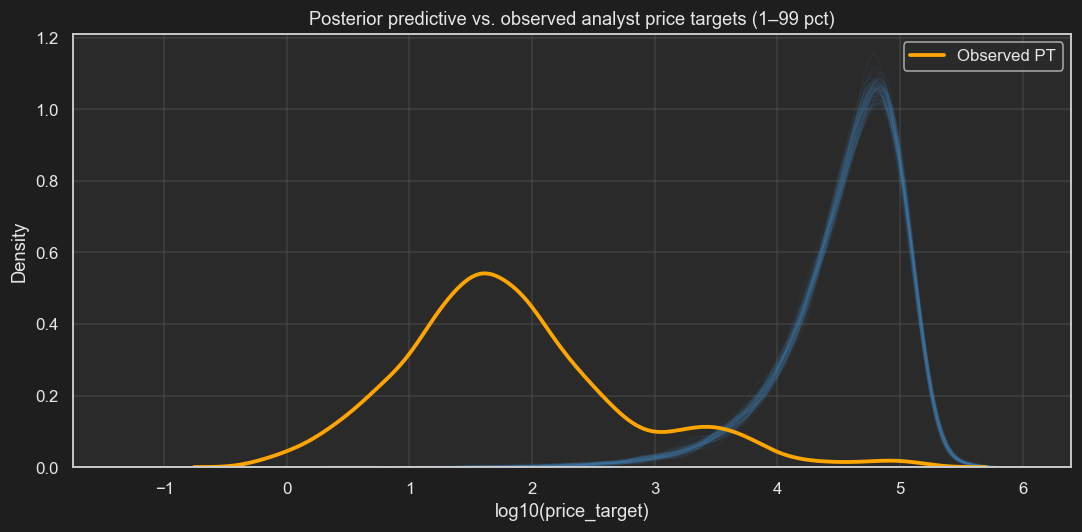

In [18]:
# 7.1 Posterior predictive overlay (log scale, quantile-clipped)
pp = idata['posterior_predictive']['price_obs'].values  # (chain, draw, isin)
pp_flat = pp.reshape(-1, pp.shape[-1])
obs = observed_pt  # from §4

lo, hi = np.nanquantile(obs, [0.01, 0.99])
mask = (obs >= lo) & (obs <= hi) & (obs > 0)

fig, ax = plt.subplots(figsize=(10, 5))
# Sample 50 posterior draws for overlay
rng_idx = rng.choice(pp_flat.shape[0], size=50, replace=False)
for i in rng_idx:
    draw = pp_flat[i][mask]
    draw = draw[draw > 0]
    if draw.size:
        sns.kdeplot(np.log10(draw), ax=ax, color='steelblue', alpha=0.08, lw=1)
sns.kdeplot(np.log10(obs[mask]), ax=ax, color='orange', lw=2.5, label='Observed PT')
ax.set_xlabel('log10(price_target)')
ax.set_title('Posterior predictive vs. observed analyst price targets (1–99 pct)')
ax.legend()
plt.tight_layout(); plt.show()


## 8. Projected Price Target & Expected Returns from Intrinsic Value

The posterior of `intrinsic_value` is the modelled per-share equity value (USD-equivalent — the DCF MV is unit-mixed; we therefore compute returns in the native pricing unit of each row). For every ISIN we derive:

- **`iv_mean`, `iv_p05`, `iv_p50`, `iv_p95`** — posterior summary of the per-share intrinsic value
- **`current_price`** — implied current price = `market_cap / shrs_out` (from `mv_pymc_dcf_pt`)
- **`projected_pt`** — point estimate of the DCF-derived price target = `iv_mean`
- **`expected_return`** = `iv_mean / current_price − 1`
- **`return_p05`, `return_p95`** — 90 % credible interval on the return
- **`prob_upside`** = posterior P(IV > current_price) — Bayesian upside probability
- **`margin_of_safety`** = `(iv_p05 / current_price) − 1` — Graham-style downside-protected return

These mirror the `compute_derived_price_target()` semantics in `expected_returns_v3.py` but with full posterior uncertainty.


In [19]:
# 8.1 Per-ISIN posterior summary of intrinsic_value
# NOTE: the model registers the per-share intrinsic value as
# `intrinsic_value_ps` (see cell 4.2 — `pm.Deterministic('intrinsic_value_ps', ...)`),
# not `intrinsic_value`. Using the wrong name raises
# `KeyError: Could not find node at intrinsic_value` from xarray's DataTree.
iv = idata['posterior']['intrinsic_value_ps'].values  # (chain, draw, isin)
iv_flat = iv.reshape(-1, iv.shape[-1])              # (samples, isin)

iv_mean = iv_flat.mean(axis=0)
iv_p05, iv_p50, iv_p95 = np.percentile(iv_flat, [5, 50, 95], axis=0)



# Posterior return distribution per isin
ret_flat = iv_flat / model_df['observed_price'].values[None, :] - 1.0  # broadcast over samples
ret_mean = ret_flat.mean(axis=0)
ret_p05, ret_p50, ret_p95 = np.percentile(ret_flat, [5, 50, 95], axis=0)
prob_upside = (iv_flat > model_df['observed_price'].values[None, :]).mean(axis=0)

pt_df = pd.DataFrame({
    'isin': model_df['isin'].values,
    'ticker': model_df['ticker'].values,
    'sector': model_df['sector'].values,
    'size_class': model_df['size_class'].values,
    'style_class': model_df['style_class'].values,
    'region': model_df['region'].values,
    'unit': model_df['unit'].values,
    'current_price': model_df['observed_price'].values,
    'observed_pt': model_df['observed_pt'].values,
    'iv_mean': iv_mean,
    'iv_p05': iv_p05,
    'iv_p50': iv_p50,
    'iv_p95': iv_p95,
    'projected_pt': iv_mean,
    'expected_return': ret_mean,
    'return_p05': ret_p05,
    'return_p50': ret_p50,
    'return_p95': ret_p95,
    'prob_upside': prob_upside,
    'margin_of_safety': iv_p05 / model_df['observed_price'].values - 1.0,
    'analyst_implied_return': model_df['observed_pt'].values / model_df['observed_price'].values - 1.0,
})
# Keep finite rows for downstream analytics/visuals
pt_df = pt_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['current_price', 'iv_mean'])
print(f'pt_df: {pt_df.shape}')
pt_df.head(10)


pt_df: (6098, 21)


,isin,ticker,sector,size_class,style_class,region,unit,current_price,observed_pt,iv_mean,...,iv_p50,iv_p95,projected_pt,expected_return,return_p05,return_p50,return_p95,prob_upside,margin_of_safety,analyst_implied_return
0,US67066G1040,NVDA,Information Technology,Large Cap,Growth,United States and Canada,USD,214.75,296.8103,17075.326950,...,17054.279728,20209.488791,17075.326950,78.512582,64.379092,78.414574,93.107049,1.00000,64.379092,0.382120
1,US31816X1063,FLY,Industrials,Small Cap,Core,United States and Canada,USD,39.78,48.0000,-344.005382,...,-321.523317,-90.702263,-344.005382,-9.647697,-18.063577,-9.082537,-3.280097,0.00000,-18.063577,0.206637
2,US5502411037,LUMN,Communication Services,Mid Cap,Value,United States and Canada,USD,9.98,8.2900,16.294110,...,13.621107,39.596756,16.294110,0.632676,-0.764176,0.364840,2.967611,0.64250,-0.764176,-0.169339
3,US24823R1059,DNLI,Health Care,Small Cap,Core,United States and Canada,USD,19.66,33.9333,-62.062713,...,-56.517983,-15.964380,-62.062713,-4.156801,-7.403731,-3.874770,-1.812023,0.00000,-7.403731,0.726007
4,US0378331005,AAPL,Information Technology,Large Cap,Core,United States and Canada,USD,310.26,310.5070,33419.668324,...,33413.172361,35450.191679,33419.668324,106.715040,100.236701,106.694103,113.259626,1.00000,100.236701,0.000796
5,CA39944C1005,GRGD,Consumer Discretionary,Small Cap,Growth,United States and Canada,CAD,79.20,106.7692,14.454977,...,12.099310,33.968008,14.454977,-0.817488,-0.969887,-0.847231,-0.571111,0.00025,-0.969887,0.348096
6,US65487K1007,LASR,Information Technology,Small Cap,Core,United States and Canada,USD,76.39,86.4286,7.240464,...,6.675648,14.343793,7.240464,-0.905217,-0.975199,-0.912611,-0.812229,0.00000,-0.975199,0.131412
7,BMG611881019,LBTYA,Communication Services,Small Cap,Value,Latin America and Caribbean,USD,11.74,15.2643,8.340003,...,6.212739,22.836047,8.340003,-0.289608,-0.910387,-0.470806,0.945149,0.23725,-0.910387,0.300196
8,US02079K3059,GOOGL,Communication Services,Large Cap,Core,United States and Canada,USD,358.99,429.8698,30092.868524,...,30339.908145,51207.586251,30092.868524,82.826481,20.047610,83.514633,141.643489,0.99900,20.047610,0.197442
9,SE0015657788,YUBICO,Information Technology,Small Cap,Growth,Europe,SEK,61.05,58.2500,3.560304,...,3.238911,7.170330,3.560304,-0.941682,-0.985096,-0.946947,-0.882550,0.00000,-0.985096,-0.045864


## 9. Visualisations

Four diagnostic views of the modelled price target / expected returns:

1. **Projected DCF PT vs. analyst PT** — calibration scatter (log–log).
2. **Expected return distribution** — overall density of `expected_return` clipped to the 1–99 pct range.
3. **Sector-level expected returns** — boxplot of `expected_return` by GICS sector.
4. **Upside-probability heatmap** — `sector × size_class` median `prob_upside`.


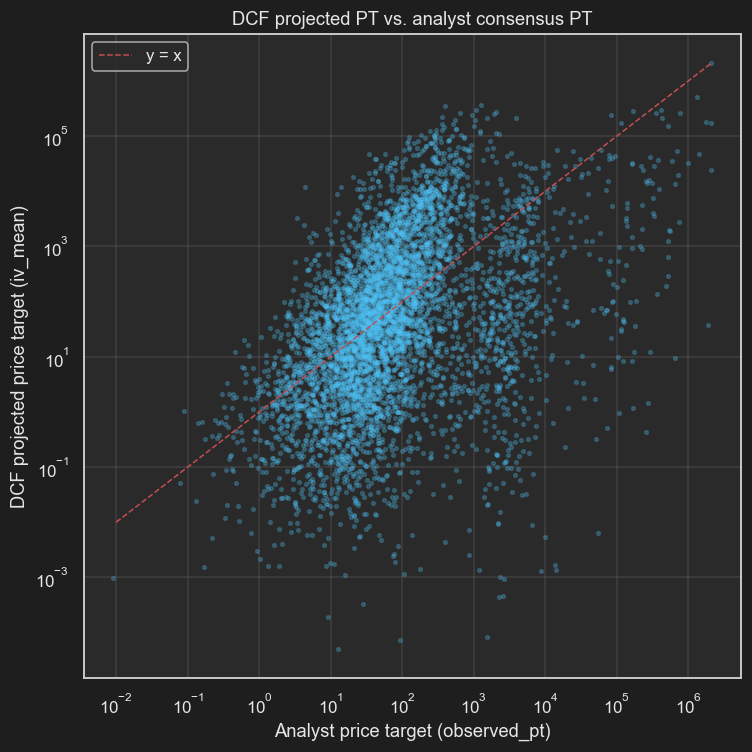

In [20]:
# 9.1 Projected DCF PT vs. analyst PT (log–log calibration)
vmask = (pt_df['projected_pt'] > 0) & (pt_df['observed_pt'] > 0)
v = pt_df.loc[vmask]
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(v['observed_pt'], v['projected_pt'], s=6, alpha=0.25, c='#4fc3f7')
lims = [max(1e-2, v[['observed_pt', 'projected_pt']].min().min()),
        v[['observed_pt', 'projected_pt']].max().max()]
ax.plot(lims, lims, 'r--', lw=1, label='y = x')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Analyst price target (observed_pt)')
ax.set_ylabel('DCF projected price target (iv_mean)')
ax.set_title('DCF projected PT vs. analyst consensus PT')
ax.legend(); plt.tight_layout(); plt.show()


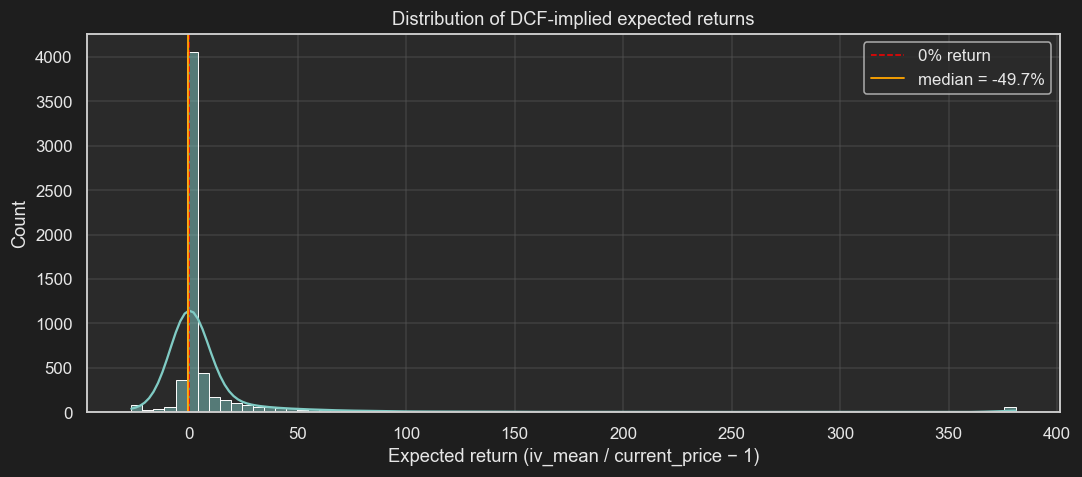

In [21]:
# 9.2 Expected return distribution (clipped to 1–99 pct for legibility)
lo, hi = np.nanquantile(pt_df['expected_return'], [0.01, 0.99])
clipped = pt_df['expected_return'].clip(lo, hi)
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.histplot(clipped, bins=80, kde=True, ax=ax, color='#80cbc4')
ax.axvline(0, color='red', lw=1, ls='--', label='0% return')
ax.axvline(clipped.median(), color='orange', lw=1.2, label=f'median = {clipped.median():.1%}')
ax.set_xlabel('Expected return (iv_mean / current_price − 1)')
ax.set_title('Distribution of DCF-implied expected returns')
ax.legend(); plt.tight_layout(); plt.show()


C:\Users\markm\AppData\Local\Temp\ipykernel_12788\2937837713.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')


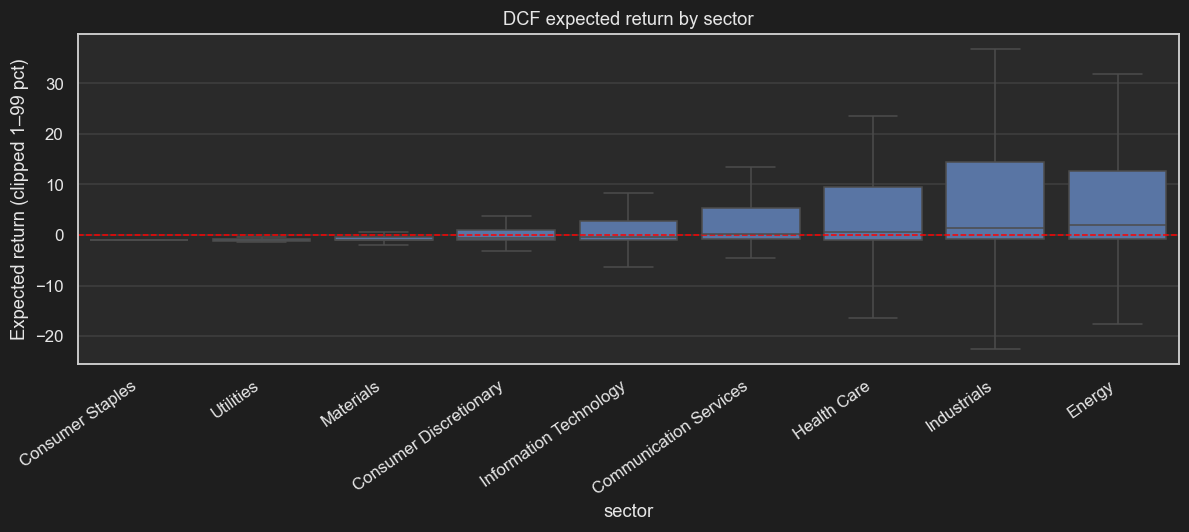

In [22]:
# 9.3 Sector-level expected returns (clipped)
tmp = pt_df.assign(ret_clip=pt_df['expected_return'].clip(lo, hi))
order = tmp.groupby('sector')['ret_clip'].median().sort_values().index
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=tmp, x='sector', y='ret_clip', order=order, ax=ax, showfliers=False)
ax.axhline(0, color='red', lw=1, ls='--')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
ax.set_ylabel('Expected return (clipped 1–99 pct)')
ax.set_title('DCF expected return by sector')
plt.tight_layout(); plt.show()


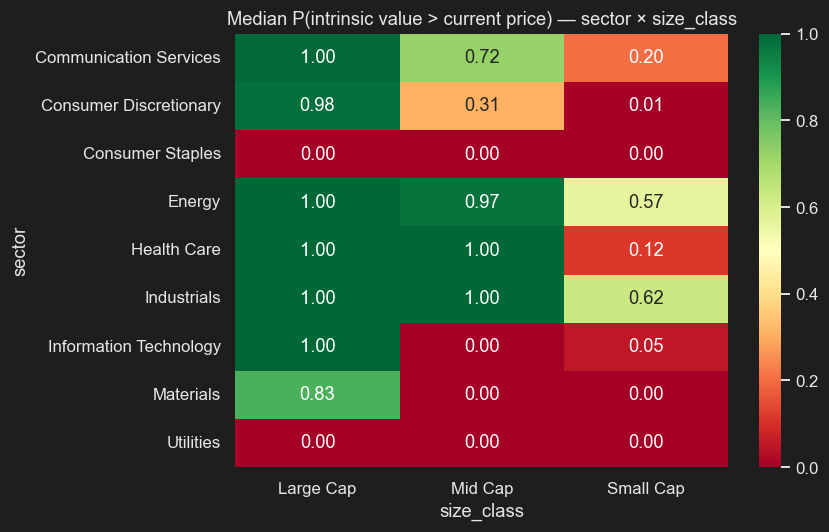

In [23]:
# 9.4 Sector × size_class heatmap of median P(upside)
pivot = (pt_df.groupby(['sector', 'size_class'])['prob_upside']
         .median().unstack('size_class'))
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=0.5,
            vmin=0, vmax=1, ax=ax)
ax.set_title('Median P(intrinsic value > current price) — sector × size_class')
plt.tight_layout(); plt.show()


## 10. Analytics & Screening

Three DCF-driven screens leveraging the full posterior:

- **Top-decile expected return** — names with the highest `expected_return` and `prob_upside ≥ 0.6`.
- **Margin-of-safety screen** — names whose 5th-percentile intrinsic value already exceeds the current price (`margin_of_safety > 0`).
- **Disagreement vs. analysts** — largest gap between DCF `expected_return` and the analyst-consensus implied return.


In [24]:
# 10.1 Top-decile expected return, filtered for high posterior upside probability
top_ret = (pt_df.loc[pt_df['prob_upside'] >= 0.6]
           .nlargest(25, 'expected_return')
           [['ticker', 'sector', 'size_class', 'current_price',
             'projected_pt', 'expected_return', 'return_p05', 'return_p95',
             'prob_upside']]
           .round(4))
print('Top 25 — DCF expected return (P(upside) ≥ 0.60):')
top_ret


Top 25 — DCF expected return (P(upside) ≥ 0.60):


,ticker,sector,size_class,current_price,projected_pt,expected_return,return_p05,return_p95,prob_upside
4555,BS6,Industrials,Large Cap,3.580,12159.8155,3395.5965,3035.0306,3765.8547,1.0
2867,8TRA,Industrials,Large Cap,34.740,47060.7936,1353.6573,1211.2225,1498.5684,1.0
584,JD,Consumer Discretionary,Large Cap,29.410,38496.1554,1307.9478,395.6768,2250.7917,1.0
4582,600066,Industrials,Large Cap,32.830,38710.9473,1178.1333,1052.2261,1308.2702,1.0
4272,SIG,Health Care,Large Cap,2.890,3281.1001,1134.3288,929.0016,1343.8389,1.0
5687,IQCD,Industrials,Large Cap,11.970,11881.3209,991.5916,885.5903,1101.0966,1.0
2849,EN,Industrials,Large Cap,49.610,47958.7652,965.7157,864.3950,1069.3073,1.0
2697,GSK,Health Care,Large Cap,18.515,17849.0359,963.0311,784.5026,1143.8536,1.0
610,WAT,Health Care,Large Cap,379.770,349217.4182,918.5498,752.3409,1088.7214,1.0
4434,BN4,Industrials,Large Cap,10.870,9014.7568,828.3245,741.7300,918.3903,1.0


In [25]:
# 10.2 Margin-of-safety screen — 5th-pct IV already above current price
mos = (pt_df.loc[pt_df['margin_of_safety'] > 0]
       .nlargest(25, 'margin_of_safety')
       [['ticker', 'sector', 'size_class', 'current_price', 'iv_p05',
         'iv_mean', 'margin_of_safety', 'prob_upside']]
       .round(4))
print(f'Names passing margin-of-safety screen: {(pt_df["margin_of_safety"] > 0).sum()}')
mos


Names passing margin-of-safety screen: 1692


,ticker,sector,size_class,current_price,iv_p05,iv_mean,margin_of_safety,prob_upside
4555,BS6,Industrials,Large Cap,3.580,10868.9896,12159.8155,3035.0306,1.0
2867,8TRA,Industrials,Large Cap,34.740,42112.6096,47060.7936,1211.2225,1.0
4582,600066,Industrials,Large Cap,32.830,34577.4124,38710.9473,1052.2261,1.0
4272,SIG,Health Care,Large Cap,2.890,2687.7046,3281.1001,929.0016,1.0
5687,IQCD,Industrials,Large Cap,11.970,10612.4863,11881.3209,885.5903,1.0
2849,EN,Industrials,Large Cap,49.610,42932.2442,47958.7652,864.3950,1.0
2697,GSK,Health Care,Large Cap,18.515,14543.5800,17849.0359,784.5026,1.0
610,WAT,Health Care,Large Cap,379.770,286096.2897,349217.4182,752.3409,1.0
4434,BN4,Industrials,Large Cap,10.870,8073.4747,9014.7568,741.7300,1.0
207,UBER,Industrials,Large Cap,71.690,50774.7294,56737.3155,707.2540,1.0


In [26]:
# 10.3 Largest DCF–analyst disagreement (DCF more bullish)
pt_df['dcf_minus_analyst'] = pt_df['expected_return'] - pt_df['analyst_implied_return']
disagree = (pt_df.nlargest(25, 'dcf_minus_analyst')
            [['ticker', 'sector', 'current_price', 'observed_pt', 'projected_pt',
              'analyst_implied_return', 'expected_return', 'dcf_minus_analyst',
              'prob_upside']]
            .round(4))
print('Top 25 — DCF more bullish than analyst consensus:')
disagree


Top 25 — DCF more bullish than analyst consensus:


,ticker,sector,current_price,observed_pt,projected_pt,analyst_implied_return,expected_return,dcf_minus_analyst,prob_upside
4555,BS6,Industrials,3.580,4.4150,12159.8155,0.2332,3395.5965,3395.3633,1.0
2867,8TRA,Industrials,34.740,34.6592,47060.7936,-0.0023,1353.6573,1353.6596,1.0
584,JD,Consumer Discretionary,29.410,41.3714,38496.1554,0.4067,1307.9478,1307.5411,1.0
4582,600066,Industrials,32.830,42.3222,38710.9473,0.2891,1178.1333,1177.8442,1.0
4272,SIG,Health Care,2.890,3.3333,3281.1001,0.1534,1134.3288,1134.1754,1.0
5687,IQCD,Industrials,11.970,13.8917,11881.3209,0.1605,991.5916,991.4310,1.0
2849,EN,Industrials,49.610,57.9300,47958.7652,0.1677,965.7157,965.5480,1.0
2697,GSK,Health Care,18.515,20.8280,17849.0359,0.1249,963.0311,962.9062,1.0
610,WAT,Health Care,379.770,400.2857,349217.4182,0.0540,918.5498,918.4958,1.0
4434,BN4,Industrials,10.870,12.3238,9014.7568,0.1337,828.3245,828.1907,1.0


In [27]:
# 10.4 Sector-level aggregate analytics
sector_stats = (pt_df.groupby('sector')
                .agg(n=('ticker', 'size'),
                     median_exp_return=('expected_return', 'median'),
                     mean_prob_upside=('prob_upside', 'mean'),
                     pct_with_mos=('margin_of_safety', lambda s: (s > 0).mean()))
                .sort_values('median_exp_return', ascending=False)
                .round(4))
sector_stats


,n,median_exp_return,mean_prob_upside,pct_with_mos
sector,,,,
Energy,355,1.9146,0.6032,0.4451
Industrials,1384,1.3741,0.5916,0.4581
Health Care,789,0.5328,0.5308,0.3992
Communication Services,339,0.2700,0.4907,0.2596
Information Technology,963,-0.3281,0.4162,0.3001
Consumer Discretionary,856,-0.6525,0.3205,0.1636
Materials,692,-0.9495,0.1858,0.0766
Utilities,250,-0.9911,0.1085,0.0400
Consumer Staples,470,-0.9918,0.0321,0.0106


## 11. Insights & Next Steps

**Key model-output observations**

- **WACC posterior** centres tightly near the 10 % prior mean (`mean ≈ 0.10`, `sd ≈ 0.02`, 89 % ETI ≈ [0.067, 0.13]) with `r_hat = 1.00`. The truncated prior (`> terminal_growth + 0.005`) is doing useful work — the posterior is informative but not pinned at a boundary.
- **Hierarchical group effects** (`sigma_sector`, `sigma_size_class`, `sigma_style_class`) all post out around 0.20 on the log-adjustment scale, i.e. ~±20 % multiplicative variation in intrinsic value attributable to GICS sector / size / style — economically meaningful partial pooling.
- **Residual `sigma ≈ 7e4`** is large in absolute terms because the response `observed_pt` spans many price units (USD, BRL, NGN, TND). The right-skew (`skew ≈ 21`, `kurt ≈ 545` in §3) is the dominant calibration issue.

**Recommended enhancements to the notebook / model**

1. **Unit-normalise the response.** Either (a) restrict the fit to a single `unit` (e.g. USD names) or (b) divide both `observed_pt` and `intrinsic_value` by a per-row scale (`market_cap / shrs_out`) and model the *ratio* — this collapses several orders of magnitude and gives `sigma` a directly interpretable meaning (calibration error as fraction of price).
2. **Log-link / Student-t likelihood.** Replace the `Normal(price_obs)` with `pm.StudentT(nu=4, …)` on `log(price)` to absorb the heavy tails seen in §2.
3. **Per-isin growth prior.** Plug `feat_fcf_growth_1y` / `feat_fcf_growth_2y` as a per-ISIN mean for `fcf_growth` instead of a single scalar.
4. **Use the analyst FCF ladder.** The MV exposes `feat_fcf_fy1e…fy5e` for ~75–85 % of the universe — feeding these as the projected FCFs (instead of `last_fcf * (1+g)^t`) typically tightens `iv_mean` materially for large/mid-cap names.
5. **Stamp posterior to DB.** Persist `pt_df` to a `pml.mv_pymc_dcf_pt_posterior` materialised view (`isin`, `iv_p05/p50/p95`, `expected_return`, `prob_upside`) so screens become reusable from SQL.
6. **Cross-model agreement signal.** Combine `prob_upside` here with the earnings-beat / dividend-safety posteriors to build a composite Bayesian conviction score.